**Importing the Required Libraries**

In [57]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import base64
import io
import sys

# Machine Learning & Stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, adjusted_rand_score
from sklearn.model_selection import train_test_split
from scipy.cluster.hierarchy import dendrogram, linkage
from imblearn.over_sampling import SMOTE

# Dash Application
from dash import Dash, dcc, html, Input, Output, State, ALL

**DATA LOADING & PREPROCESSING**

In [59]:
# Importing the dataset
path = 'base data.csv'
df = pd.read_csv(path) # Load csv into a dataframe
'''
print('='*90)
print(df.head()) #visualise the first 5 rows

# Visualise data distribution and data summary
print('='*90)
print(df.describe())
'''
print('='*90)
print(df.info()) # View data distribution

df = df[df['CONTROLLER_ERROR_CODE'].str.isnumeric()].dropna() #remove rows with multiple errors
print(df['CONTROLLER_ERROR_CODE'].value_counts())

# Filter dataset to the top 5 most frequent error codes
top_5_errors = df['CONTROLLER_ERROR_CODE'].value_counts().nlargest(5).index
print(f"Top 5 Individual Error Codes: {list(top_5_errors)}")

df_filtered = df[df['CONTROLLER_ERROR_CODE'].isin(top_5_errors)].copy()

# Define Features (X) and Target (y)
X = df_filtered.drop(columns=['CONTROLLER_ERROR_CODE'])
y = df_filtered['CONTROLLER_ERROR_CODE']

# Balance Classes using SMOTE
print("Applying SMOTE balancing...")
smote = SMOTE(random_state=42, k_neighbors=1)
X_resampled, y_resampled = smote.fit_resample(X, y)

# Correlation Reduction (Drop features > 85% correlated)
corr_matrix = X_resampled.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.8)]
X_reduced = X_resampled.drop(columns=to_drop)

# Rename Column Names
variable_description = {
    'CONTROLLERTEMPERATUREPUMP' : 'Controller Temp - Pump',
    'BATTERYCURRENTPUMP': 'Battery Current - Pump',
    'MOTORTEMPERATUREREAR': 'Motor Temperature',
    'BATTERYLOWESTCELLVOLTAGE': 'Lowest Cell Voltage',
    'MOTORTORQUEFR': 'Motor Torque - FR',
    'MOTORRPMPUMP': 'Motor RPM - Pump',
    'BATTERYARRAYCURRENT': 'Battery Array Current',
    'BATTERYCURRENTFR': 'Battery Current - FR',
    'BATTERYCURRENTREAR': 'Battery Current - Rear',
    'BATTERYPOWERPUMP': 'Battery Power - Pump',
    'MOTORTORQUEREAR': 'Motor Torque - Rear',
    'MOTORPOWERPUMP': 'Motor Power - Pump',
    'MOTORPOWERREAR': 'Motor Power - Rear',
    'BATTERYARRAYVOLTAGE': 'Battery Array Voltage',
    'BATTERYSTATEOFCHARGE': 'Battery SOC',
    'MOTORPOWERFL': 'Motor Power - FL',
    'MOTORTORQUEFL': 'Motor Torque - FL',
    'MOTORTORQUEPUMP': 'Motor Torque - Pump',
    'STEERANGLEPUMP': 'Steer Angle - Pump',
    'CONTROLLERTEMPERATUREFR': 'Controller Temperature - FR',
    'BATTERYSYSTEMHIGHTEMPERATURE': 'Battery System High Temperature',
    'MOTORTEMPERATUREFL': 'Motor Temperature - FL',
    'MOTORTEMPERATUREPUMP': 'Battery Temperature - Pump',
    'BATTERYCURRENTFL': 'Battery Current - FL',
    'MOTORRPMFR': 'Motor RPM - FR',
    'MOTORTEMPERATUREFR': 'Motor Temperature - FR',
    'MOTORPOWERFR': 'Motor Power - FR'
}
X_reduced = X_reduced.rename(columns=variable_description)

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_reduced)
le = LabelEncoder()
y_encoded = le.fit_transform(y_resampled)


print("Applying SMOTE to balance classes...")
print(f"Original shape: {X_resampled.shape}, Resampled shape: {X_reduced.shape}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3892 entries, 0 to 3891
Data columns (total 35 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CONTROLLER_ERROR_CODE         3892 non-null   object 
 1   CONTROLLERTEMPERATUREPUMP     3125 non-null   float64
 2   BATTERYCURRENTPUMP            3130 non-null   float64
 3   MOTORTEMPERATUREREAR          3125 non-null   float64
 4   BATTERYLOWESTCELLVOLTAGE      3103 non-null   float64
 5   MOTORTORQUEFR                 2244 non-null   float64
 6   MOTORRPMPUMP                  3130 non-null   float64
 7   BATTERYARRAYCURRENT           3103 non-null   float64
 8   BATTERYCURRENTFR              2244 non-null   float64
 9   BATTERYCURRENTREAR            3130 non-null   float64
 10  CONTROLLERTEMPERATUREFR       2244 non-null   float64
 11  BATTERYPOWERPUMP              3130 non-null   float64
 12  MOTORTORQUEREAR               3130 non-null   float64
 13  MOT

**Observations:**
1. Each feature has a different count ranging from 2240 to 3130 (many null values) and varying range for different features. Hence the need for Data Cleaning and Normalisation in the preprocessing phase. Also, the CONTROLLER_ERROR_CODE is a vector with multiple error codes. This will also be split up into it's individual columns

2. Rows with multi variables cause poor performamnce
3. The dataset is very imbalanced - used SMOTE to balance dataset

**MODELING**

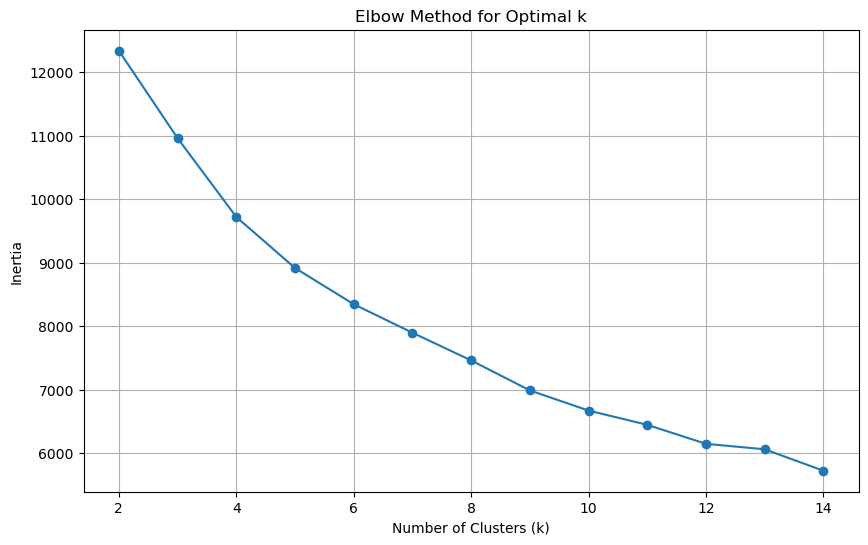

In [46]:
# Generate Elbow Chart (k=2 to 15)
inertia = []
k_range = range(2, 15)
for k_val in k_range:
    km = KMeans(n_clusters=k_val, random_state=42, n_init=5)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='-')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.savefig('elbow_plot_refined.png')


In [ ]:
# Unsupervised Learning (Clustering)
# k=4 was selected based on the Elbow Method (point of diminishing returns).

k = 4 # k mean parameter selected based on the elbow curve

# K-Means: Partition data into k clusters by minimizing variance within clusters.
kmeans_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
ari_kmeans = adjusted_rand_score(y_encoded, kmeans_labels)

# Agglomerative: Hierarchical clustering using Ward's method to minimize variance when merging.
agglo_labels = AgglomerativeClustering(n_clusters=k, linkage='ward').fit_predict(X_scaled)
ari_agglo = adjusted_rand_score(y_encoded, agglo_labels)

# GMM: Probabilistic model 
gmm_labels = GaussianMixture(n_components=k, random_state=42).fit_predict(X_scaled)
ari_gmm = adjusted_rand_score(y_encoded, gmm_labels)

# Supervised (Random Forest)
# Split data: 70% for training the model, 30%
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42)

# Random Forest: Ensemble of 100 decision trees.
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred)

**PREPARE VISUALIZATION DATA**

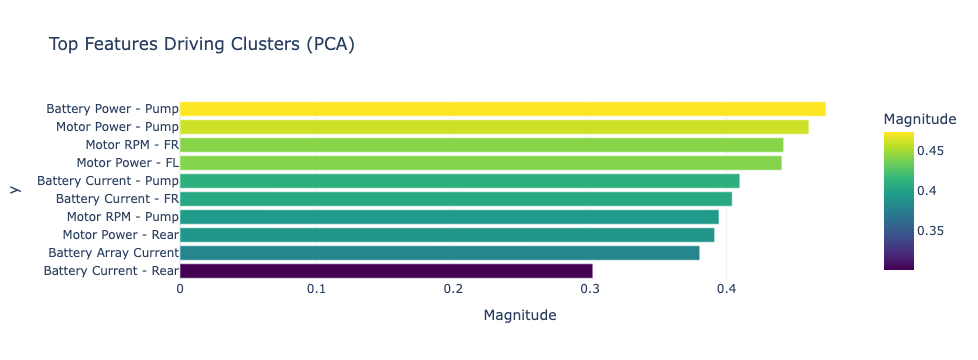

In [50]:
# PCA Projection
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled) # Fit PCA on the scaled data and transform it into the new 2D coordinates.

# Create a DataFrame for visualization to hold all necessary plotting data.
df_vis = pd.DataFrame(data=components, columns=['PC1', 'PC2'])

# Add the original class labels (decoded from numbers back to error names).
df_vis['Ground_Truth'] = le.inverse_transform(y_encoded)

# Add the predicted cluster labels from all three unsupervised models.
df_vis['KMeans_Label'] = kmeans_labels
df_vis['Agglo_Label'] = agglo_labels
df_vis['GMM_Label'] = gmm_labels

# Dynamic Feature Selection via PCA Loadings
# Identify which features drive the separation in PC1/PC2 space
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=X_reduced.columns)
loadings['Magnitude'] = np.sqrt(loadings['PC1']**2 + loadings['PC2']**2)
features_to_plot = loadings.nlargest(5, 'Magnitude').index.tolist()

# Add these features to df_vis for the Parallel Coordinates plot
for col in features_to_plot:
    df_vis[col] = X_reduced[col].values

# Extract feature importance scores from the trained Random Forest model.
importances = rf.feature_importances_
# Create a sorted DataFrame to rank features by their predictive power.
feature_importance_df = pd.DataFrame({'Feature': X_reduced.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

# Select the top 5 most critical features for the User Input form in the dashboard.
top_5_features = feature_importance_df.head(5)['Feature'].tolist()

# Calculate the mean of every feature to use as default values for missing inputs.
feature_means = X_reduced.mean()

# Create a horizontal bar chart showing the top 10 features driving the PCA spread.
fig_pca_imp = px.bar(
    loadings.nlargest(10, 'Magnitude'), 
    x='Magnitude', 
    y=loadings.nlargest(10, 'Magnitude').index, 
    orientation='h', 
    title="Top Features Driving Clusters (PCA)",
    template='plotly_white', 
    color='Magnitude', 
    color_continuous_scale='Viridis'
)
# Ensure the most important feature is at the top of the chart.
fig_pca_imp.update_layout(yaxis={'categoryorder':'total ascending'})

In [51]:
# Output Results
print(f"Top 10 Individual Error Codes: {list(top_5_errors)}")
print(f"\nClustering Results with k={k}:")
print(f"1. K-Means ARI: {ari_kmeans:.4f}")
print(f"2. Agglomerative ARI: {ari_agglo:.4f}")
print(f"3. GMM ARI: {ari_gmm:.4f}")

Top 10 Individual Error Codes: ['29', '92', '58', '39', '69']

Clustering Results with k=4:
1. K-Means ARI: 0.2165
2. Agglomerative ARI: 0.1916
3. GMM ARI: 0.1609


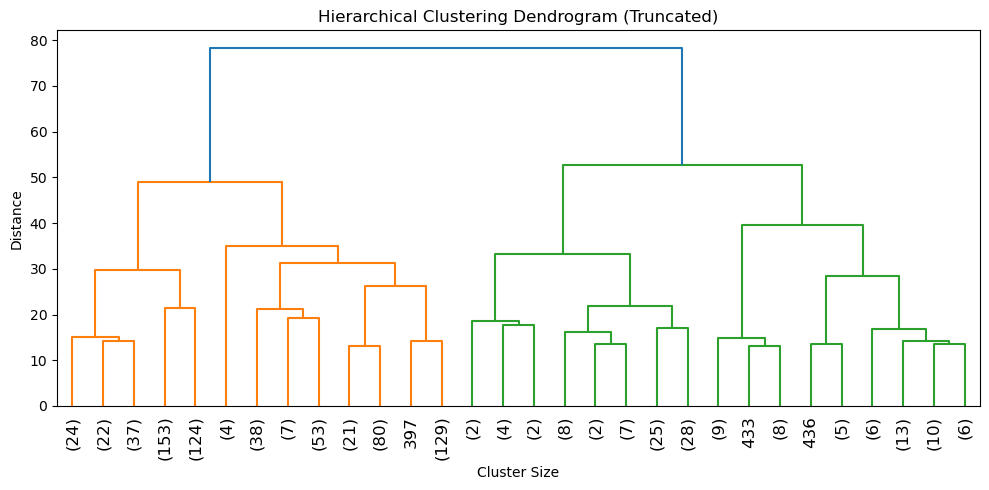

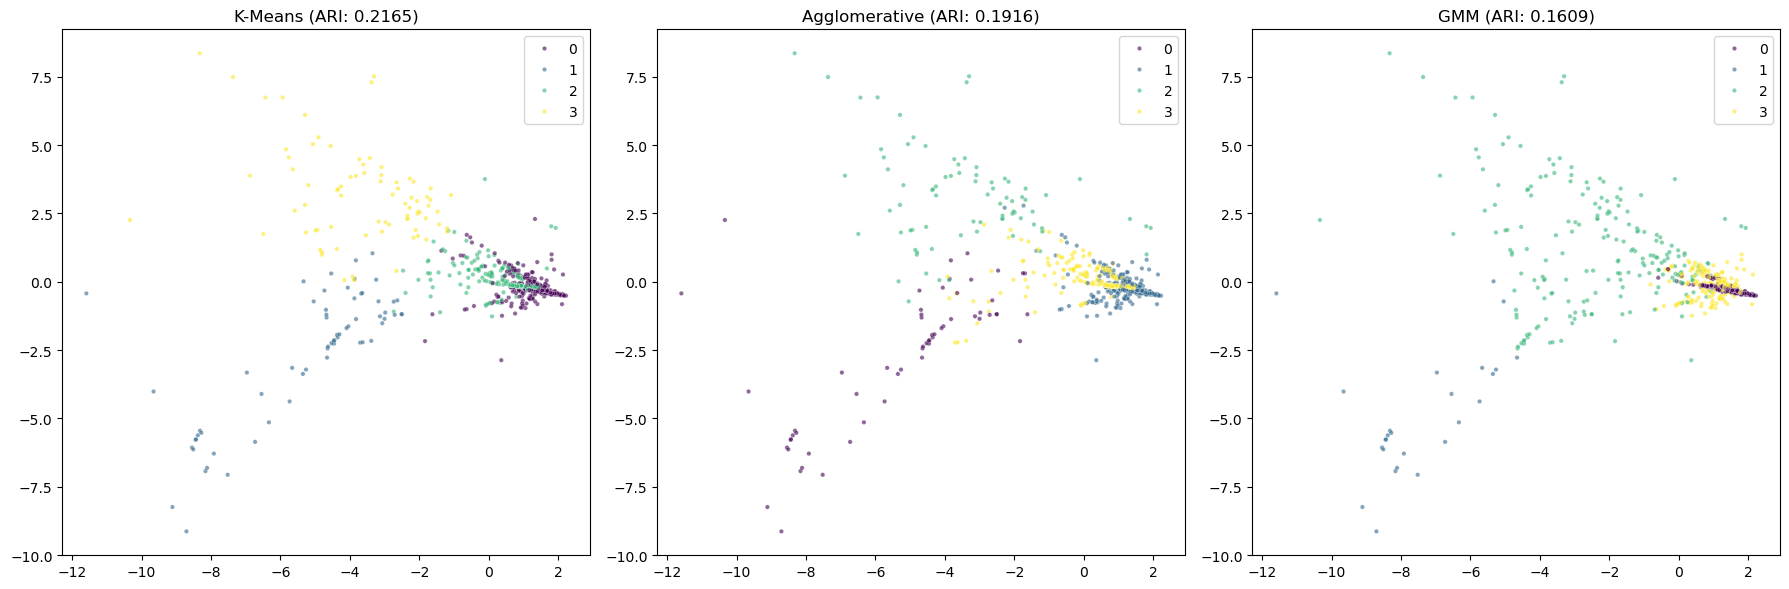

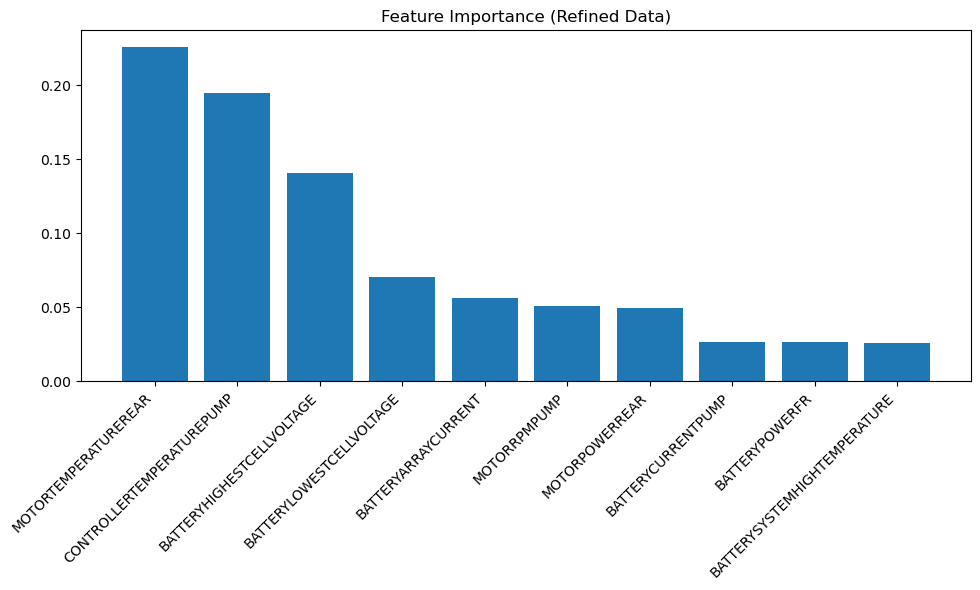

In [52]:
# Visualizations

# Dendrogram (Hierarchical Clustering)
# Initialize a figure for the dendrogram with a specified size.
plt.figure(figsize=(10, 5))
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Cluster Size') # X-axis represents the size of merged clusters
plt.ylabel('Distance') # Y-axis represents the distance (dissimilarity) at which merges occur

# Compute the linkage matrix 'Z' using Ward's method.
Z = linkage(X_scaled, method='ward')

# Plot the dendrogram using the computed linkage matrix.
# truncate_mode='lastp': Only show the last 'p' merged clusters to keep the plot readable.
# p=30: Show only the top 30 clusters/branches.
# show_contracted=False: Do not show contraction marks for hidden branches.
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=12., show_contracted=False)
plt.tight_layout()
plt.savefig('dendrogram_refined.png')

# Cluster Comparison
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# K-Means
# Scatter plot of PC1 vs PC2, colored by K-Means cluster labels.
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='viridis', s=10, ax=axes[0], alpha=0.6)
axes[0].set_title(f'K-Means (ARI: {ari_kmeans:.4f})')

# Agglomerative
# Scatter plot of PC1 vs PC2, colored by Agglomerative cluster labels.
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=agglo_labels, palette='viridis', s=10, ax=axes[1], alpha=0.6)
axes[1].set_title(f'Agglomerative (ARI: {ari_agglo:.4f})')

# GMM
# Scatter plot of PC1 vs PC2, colored by GMM cluster labels.
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=gmm_labels, palette='viridis', s=10, ax=axes[2], alpha=0.6)
axes[2].set_title(f'GMM (ARI: {ari_gmm:.4f})')

plt.tight_layout()
plt.savefig('clustering_comparison_refined.png')

# Extract feature importance scores from the trained Random Forest model.
importances = rf.feature_importances_

# Sort the feature indices based on importance scores in descending order.
indices = np.argsort(importances)[::-1]

# Get the names of the features
feature_names = X.columns

# Create a bar chart showing the importance of the top 10 features.
# importances[indices[:10]]: Get the importance scores of the top 10 features.
plt.figure(figsize=(10, 6))
plt.title("Feature Importance (Refined Data)")
plt.bar(range(10), importances[indices[:10]], align="center")
plt.xticks(range(10), feature_names[indices[:10]], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('feature_importance_refined.png')

In [24]:
# Output Results
print("Refined Preprocessing Results:")
print(f"Top 10 Individual Error Codes: {list(top_5_errors)}")
print(f"K-Means ARI: {ari_kmeans:.4f}")
print(f"Agglomerative ARI: {ari_agglo:.4f}")
print(f"GMM ARI: {ari_gmm:.4f}")
print("\nRandom Forest Classification Report (Refined):")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in le.classes_]))

Refined Preprocessing Results:
Top 10 Individual Error Codes: ['29', '92', '58', '39', '69']
K-Means ARI: 0.1991
Agglomerative ARI: 0.2909
GMM ARI: 0.1653

Random Forest Classification Report (Refined):
              precision    recall  f1-score   support

          29       0.98      0.96      0.97        46
          39       0.92      0.98      0.95        46
          58       0.98      0.91      0.94        55
          69       0.98      0.98      0.98        45
          92       0.90      0.93      0.91        57

    accuracy                           0.95       249
   macro avg       0.95      0.95      0.95       249
weighted avg       0.95      0.95      0.95       249



In [53]:
# GENERATE STATIC IMAGE
plt.figure(figsize=(8, 5))

# Create a scatter plot to visualize the clusters in 2D PCA space.
# x, y: The principal components (PC1, PC2).
# hue: Color points based on the 'Agglo_Label' (Agglomerative Clustering results).
# palette: Color scheme ('viridis').
# s: Marker size (50).
# alpha: Transparency (0.7) to see overlapping points.
sns.scatterplot(x='PC1', y='PC2', hue='Agglo_Label', data=df_vis, palette='viridis', s=50, alpha=0.7)
plt.title('Static View: Agglomerative Clustering (k=4)')

# Add a grid to the background 
plt.grid(True, linestyle='--', alpha=0.5)
buf = io.BytesIO() 
plt.savefig(buf, format='png')
plt.close()
buf.seek(0)
encoded_image = base64.b64encode(buf.read()).decode('ascii')

In [56]:

# APP LAYOUT
# Load external CSS for a grid-based layout 
external_stylesheets = ['https://codepen.io/chriddyp/pen/bWLwgP.css']
app = Dash(__name__, external_stylesheets=external_stylesheets)


app.layout = html.Div([
    # Main Dashboard Title
    html.H2("ETMFL Predictive Maintenance Dashboard", style={'textAlign': 'center', 'color': '#2c3e50'}),

    # Split into tabs for better organization
    dcc.Tabs([
        # --- TAB 1: UNSUPERVISED ---
        # Tab for clustering results (K-Means, Agglomerative, GMM)
        dcc.Tab(label='Unsupervised Analysis', children=[
            html.Div([
                html.H4("Cluster Analysis", style={'textAlign': 'center', 'marginTop': '20px'}),

                # Static PCA Scatter Plot
                # Shows the "best" model's clustering result 
                html.Div([
                   html.Img(src='data:image/png;base64,{}'.format(encoded_image), style={'height': '300px', 'display': 'block', 'margin': 'auto', 'border': '1px solid #ddd', 'padding': '5px'})
                ], style={'marginBottom': '20px'}),

                # Controls - Algorithm Selector Dropdown
                # Allows the user to switch between clustering algorithms dynamically.
                html.Div([
                    html.Label("Select Algorithm:", style={'fontWeight': 'bold'}),
                    dcc.Dropdown(
                        id='algo-dropdown',
                        options=[
                            {'label': 'Agglomerative (Best)', 'value': 'Agglo_Label'},
                            {'label': 'K-Means', 'value': 'KMeans_Label'},
                            {'label': 'GMM', 'value': 'GMM_Label'}
                        ],
                        value='Agglo_Label',
                        clearable=False
                    )
                ], style={'width': '50%', 'margin': 'auto', 'marginBottom': '20px'}),

                # Graphs - Interactive Graphs
                # Left: Scatter Plot of clusters in 2D PCA space.
                # Right: Confusion Matrix comparing Clusters to True Error Codes.
                html.Div([
                    html.Div([dcc.Graph(id='cluster-scatter')], className='six columns'),
                    html.Div([dcc.Graph(id='confusion-heatmap')], className='six columns')
                ], className='row'),

                # Interactive Graphs 
                # Bottom: Parallel Coordinates plot to show the physical sensor profile of each cluster.
                html.Div([
                    html.H5("Operational Profile", style={'textAlign': 'center'}),
                    dcc.Graph(id='parallel-coords')
                ], className='row')
            ])
        ]),

        # --- TAB 2: SUPERVISED ---
        # Focuses on the Random Forest classification results
        dcc.Tab(label='Supervised Analysis', children=[
            html.Div([
                html.H4(f"Random Forest Performance (Accuracy: {rf_accuracy:.2%})", style={'textAlign': 'center', 'marginTop': '20px', 'color': '#2a9d8f'}),

                html.Div([
                    html.Div([
                        html.H5("Confusion Matrix", style={'textAlign': 'center'}),
                        dcc.Graph(id='rf-confusion-matrix')
                    ], className='six columns'),

                    html.Div([
                        html.H5("Top Feature Importance", style={'textAlign': 'center'}),
                        dcc.Graph(id='rf-feature-importance')
                    ], className='six columns')
                ], className='row'),

                html.Div([
                    html.H5("Classification Report", style={'textAlign': 'center'}),
                    html.Div(id='rf-metrics-table', style={'margin': '20px', 'textAlign': 'center'})
                ], className='row')
            ])
        ]),

        # --- TAB 3: PREDICTION TOOL ---
        # Allows users to input sensor data and get a real-time failure prediction
        dcc.Tab(label='Prediction Tool', children=[
            html.Div([
                html.H4("Real-time Failure Prediction", style={'textAlign': 'center', 'marginTop': '30px'}),
                html.P("Enter sensor values below. Unspecified sensors will use average values.", style={'textAlign': 'center', 'color': '#7f8c8d'}),

                # Dynamic Input Fields for Top 5 Features
                # Automatically generates input boxes for the Top 5 most important features.
                # Default value is the mean from the training set.
                html.Div([
                    html.Div([
                        html.Label(feat, style={'fontWeight': 'bold'}),
                        dcc.Input(
                            id={'type': 'pred-input', 'index': feat},
                            type='number',
                            placeholder=f"Avg: {feature_means[feat]:.2f}",
                            value=round(feature_means[feat], 2), # Default to mean
                            style={'width': '100%'}
                        )
                    ], className='two columns') for feat in top_5_features
                ], className='row', style={'padding': '20px', 'display': 'flex', 'justifyContent': 'center'}),
                
                # Predict Button
                html.Div([
                    html.Button('Predict Failure', id='btn-predict', n_clicks=0, className='button-primary', style={'fontSize': '18px'})
                ], style={'textAlign': 'center', 'marginTop': '20px'}),

                # Prediction Output Result
                html.Div(id='prediction-output', style={'textAlign': 'center', 'marginTop': '30px', 'padding': '20px'})

            ], style={'backgroundColor': '#f4f6f7', 'padding': '40px', 'borderRadius': '10px', 'margin': '20px'})
        ])
    ])
])

# CALLBACKS (INTERACTIVITY LOGIC)

# Callback 1: Update Unsupervised Graphs
# Triggered when 'algo-dropdown' changes. Updates Scatter, Heatmap, and Parallel Coords.
@app.callback(
    [Output('cluster-scatter', 'figure', allow_duplicate=True),
     Output('confusion-heatmap', 'figure'),
     Output('parallel-coords', 'figure')],
    [Input('algo-dropdown', 'value')],
    prevent_initial_call='initial_duplicate'
)
def update_unsupervised(selected_algo):
    # Scatter Plot: Colors points by the selected algorithm's labels
    fig_scatter = px.scatter(df_vis, x='PC1', y='PC2', color=df_vis[selected_algo].astype(str), 
                             title=f"Cluster Separation - {selected_algo}", template='plotly_white')

    # Heatmap: Shows agreement between clusters and ground truth error codes
    conf_matrix = pd.crosstab(df_vis['Ground_Truth'], df_vis[selected_algo])
    fig_heatmap = go.Figure(data=go.Heatmap(z=conf_matrix.values, x=conf_matrix.columns, y=conf_matrix.index, colorscale='Blues'))
    fig_heatmap.update_layout(title="Confusion Matrix", xaxis_title="Cluster", yaxis_title="True Error")

    # Parallel Coords: Plots the mean sensor profile for each cluster
    cluster_profile = df_vis.groupby(selected_algo)[features_to_plot].mean().reset_index()
    fig_parcoords = px.parallel_coordinates(cluster_profile, color=selected_algo, dimensions=features_to_plot, color_continuous_scale=px.colors.diverging.Tealrose)
        
    return fig_scatter, fig_heatmap, fig_parcoords

# Callback 2: Update Supervised Graphs
# Updates the Random Forest metrics when the dropdown changes.
@app.callback(
    [Output('rf-confusion-matrix', 'figure'),
     Output('rf-feature-importance', 'figure'),
     Output('rf-metrics-table', 'children')],
    [Input('algo-dropdown', 'value')]
)
def update_supervised(_):
    # Confusion Matrix for Random Forest
    cm = confusion_matrix(y_test, y_pred)
    labels = le.inverse_transform(sorted(list(set(y_test))))
    fig_cm = go.Figure(data=go.Heatmap(z=cm, x=labels, y=labels, colorscale='Greens', text=cm, texttemplate="%{text}"))
    fig_cm.update_layout(title="Confusion Matrix (Supervised)", xaxis_title="Predicted", yaxis_title="Actual")

    # Feature Importance Bar Chart
    fig_imp = px.bar(feature_importance_df.head(10), x='Importance', y='Feature', orientation='h', title="Random Forest Feature Importance", template='plotly_white')
    fig_imp.update_layout(yaxis={'categoryorder':'total ascending'})

    # Classification Report Table
    report = classification_report(y_test, y_pred, target_names=[str(l) for l in labels], output_dict=True)
    rows = [html.Tr([html.Th("Class"), html.Th("Precision"), html.Th("Recall"), html.Th("F1-Score")])]
    for label, metrics in report.items():
        if isinstance(metrics, dict):
            rows.append(html.Tr([
                html.Td(label),
                html.Td(f"{metrics['precision']:.2f}"),
                html.Td(f"{metrics['recall']:.2f}"),
                html.Td(f"{metrics['f1-score']:.2f}")
            ]))
    return fig_cm, fig_imp, html.Table(rows, className='table', style={'width': '80%', 'marginLeft': 'auto', 'marginRight': 'auto'})

# Callback 3: Prediction Logic
# Takes user inputs, imputes missing values with means, scales data, and predicts using the trained Random Forest model.
@app.callback(
    Output('prediction-output', 'children'),
    [Input('btn-predict', 'n_clicks')],
    [State({'type': 'pred-input', 'index': ALL}, 'value'),
     State({'type': 'pred-input', 'index': ALL}, 'id')]
)
def predict_failure(n_clicks, input_values, input_ids):
    if n_clicks == 0: return ""

    # Construct input vector (starting with means)
    input_vector = feature_means.copy()
    for val, id_dict in zip(input_values, input_ids):
        if val is not None:
            input_vector[id_dict['index']] = val

    # Scale and Predict
    input_df = pd.DataFrame([input_vector], columns=X_reduced.columns)
    input_scaled = scaler.transform(input_df)
    
    prediction_code = rf.predict(input_scaled)[0]
    prediction_prob = np.max(rf.predict_proba(input_scaled))
    decoded_error = le.inverse_transform([prediction_code])[0]

    # Return Result
    return html.Div([
        html.H3(f"Predicted Error Code: {decoded_error}", style={'color': '#e74c3c', 'fontWeight': 'bold'}),
        html.H5(f"Confidence: {prediction_prob:.2%}", style={'color': '#7f8c8d'})
    ])

if __name__ == '__main__':
    print("Dash is running. Open this link: http://127.0.0.1:8055/")
    app.run(debug=False, host='0.0.0.0', port=8055)

Dash is running. Open this link: http://127.0.0.1:8055/
